# Tools Demo — **FileSearch + CodeInterpreter** with Responses API (Azure OpenAI)

In this third notebook we go beyond simple conversations and show how to:
- Set up a **Vector Store** and upload files for **File Search**
- Run **Python in a sandbox** via **Code Interpreter** (e.g., data analysis & plotting)
- Retrieve **generated files** from the Code Interpreter container

> ℹ️ **Why these tools?**  
> - **File Search** lets the model retrieve facts from your private documents directly in a Responses API call. [1](https://platform.openai.com/docs/guides/tools-file-search)  
> - **Code Interpreter** provides a secure Python sandbox so the model can write/run code and generate outputs (images, CSVs, etc.). [2](https://platform.openai.com/docs/guides/tools-code-interpreter)

---

## Prerequisites

- Python `openai` package (`pip install openai`)  
- Azure OpenAI resource + a model deployment (e.g., `gpt-4.1`/`gpt‑4o` variants)  
- Environment variables:
  - `AZURE_OPENAI_API_KEY`
  - `AZURE_OPENAI_ENDPOINT` (e.g., `https://<your-resource>.openai.azure.com`)
  - `MODEL_DEPLOYMENT_NAME` (your **deployment name**, not base model id; Azure samples use model deployment names with the Responses v1 API) [3](https://github.com/Azure-Samples/azure-openai-responses-api-samples)

> ✅ **Endpoint note (Responses v1)**  
> Most recent Azure samples recommend the **`/openai/v1/`** base URL with the OpenAI SDK, which simplifies usage versus per‑version query params. [3](https://github.com/Azure-Samples/azure-openai-responses-api-samples)

## [Disclaimer by OpenAI](https://platform.openai.com/docs/assistants/migration?user-chat-app=responses)
*After achieving feature parity in the Responses API, we've deprecated the Assistants API. It will shut down on August 26, 2026. Follow the guidance below to update your integration. [Learn more](https://platform.openai.com/docs/guides/migrate-to-responses).*

# Authentication & Environment setup

In [1]:
import sys
from dotenv import load_dotenv # package python-dotenv
config_path = "../../config"
sys.path.append(config_path)
from auth import acquire_bearer_token
bearer_token, user = acquire_bearer_token(auth_method="default") # default, cli, device

if not load_dotenv(f"{config_path}/credentials_my.env"):
    print("Environment variables not loaded, cell execution stopped")
else:
    print("Environment variables have been loaded ;-)")

print("Bearer token:", bearer_token[:10], "...")
print(f'User info: {user["name"]}, upn: {user["upn"]}')
# user['raw_claims']

Environment variables have been loaded ;-)
Bearer token: eyJ0eXAiOi ...
User info: Mauro Minella, upn: mauro.minella@MngEnvMCAP883652.onmicrosoft.com


# Constants and Libraries

In [2]:
import os
from IPython.display import Markdown, Image, display
from openai import AzureOpenAI # package openai

project_openai_endpoint = os.getenv("AIF_STD_PROJECT_OPENAI_ENDPOINT")
deployment_name=os.environ["MODEL_DEPLOYMENT_NAME"]
openai_api_version = os.getenv("AZURE_OPENAI_API_VERSION")

messages_system = "You are an AI assistant that helps people find information"
question1 = "What are the top 3 features of the trailmaster?"
question2 = "Analyze the turbines CSV file and produce insights + a chart."

# Create a client to connec to Azure OpenAI service and deployment

In [3]:
# Note: Applications require bearer token auth; API keys are not supported at this time.
client = AzureOpenAI(
    azure_endpoint=project_openai_endpoint.rstrip("/") + "/",
    api_key="__unused__",  # placeholder; we will send OAuth header
    default_headers={"Authorization": f"Bearer {bearer_token}"},
    api_version = openai_api_version,
)

print(f"OpenAI Endpoint base_url: {client.base_url}")

OpenAI Endpoint base_url: https://aifv2-01-std-foundry.openai.azure.com/openai/


# FILE SEARCH

In [4]:
# Create a vector store (your private knowledge base)
vector_store = client.vector_stores.create(name="my_kb")

# Upload and attach local files (e.g., PDFs, DOCX, TXT) to the vector store
file_paths = ["data/product_01.md"]  # adjust paths
file_ids = []
for p in file_paths:
    f = client.files.create(file=open(p, "rb"), purpose="assistants")
    client.vector_stores.files.create(vector_store_id=vector_store.id, file_id=f.id)
    file_ids.append(f.id)

print("VectorStore ID:", vector_store.id)
print("Uploaded File IDs:", file_ids)

VectorStore ID: vs_sSSM3FfkvLztkgFXGL97CVYh
Uploaded File IDs: ['assistant-8fRSrJcmM24bZf59tAZ8aG']


## Just for testing: list files and eventually delete them

In [5]:
file_list = client.files.list().data
for f in file_list:
    print(f"{f.id} --> {f.filename}")

if len(file_list) > 0:
    confirm_deletion = input(f"do you want to delete {len(file_list)} file(s)? (y/N)")
    if str.lower(confirm_deletion[0]) == 'y':
        for f in file_list:
            client.files.delete(file_id=f.id)
            print(f"File {f.filename} ({f.id}) deleted!")

assistant-8fRSrJcmM24bZf59tAZ8aG --> product_01.md
assistant-AbQ5wXe3cArDcVp6L6jnmD --> product_01.md


do you want to delete 2 file(s)? (y/N) y


File product_01.md (assistant-8fRSrJcmM24bZf59tAZ8aG) deleted!
File product_01.md (assistant-AbQ5wXe3cArDcVp6L6jnmD) deleted!


## First File Search query via Responses API
Attach the file_search tool and point it to our vector_store_id.<br/>
Optionally, request raw search results in the output using include=["file_search_call.results"]

In [6]:
resp_fs = client.responses.create(
    model=deployment_name,
    input=question1,
    tools=[{
        "type": "file_search",
        "vector_store_ids": [vector_store.id],
        "max_num_results": 5  # optional
    }],
    include=["file_search_call.results"]  # include raw retrieval info for transparency
)

display(Markdown(resp_fs.output_text))

The top 3 features of the TrailMaster X4 tent are:

1. **Spacious Interior**: It can comfortably accommodate up to 4 people with room for gear, providing ample space for camping trips.

2. **Easy Setup**: The tent is designed for easy assembly and includes instructions, making it convenient even for novice campers.

3. **Water-Resistant Construction**: The tent features a waterproof design that effectively keeps occupants dry during light rain.

# CODE INTERPRETER
To let the model analyze a dataset, add the Code Interpreter tool with a container set to {"type": "auto"} and mount the CSV via file_ids.<br/>
These are the documented fields for Code Interpreter in the Responses API

In [7]:
# Upload a local CSV (e.g., sales) to mount in the Code Interpreter container
csv = client.files.create(file=open("data/turbines.csv", "rb"), purpose="assistants")

# Configure Code Interpreter as a tool with an auto container and mounted file
code_tool = {
    "type": "code_interpreter",
    "container": {
        "type": "auto",
        "memory_limit": "1g",     # optional (default ~1 GB)
        "file_ids": [csv.id]      # mount the uploaded CSV
    }
}

In [8]:
resp_ci = client.responses.create(
    model=deployment_name,
    instructions=(
        "You are a data analyst. Use the python tool to compute revenue"
    ),
    input="Analyze the mounted CSV file and produce insights + a chart.",
    tools=[code_tool],
    include=["code_interpreter_call.outputs"]
)

display(Markdown(resp_ci.output_text))

The dataset contains the following columns:

- **Turbine_ID**: Unique identifier for each turbine.
- **Wind_Speed**: Recorded wind speed.
- **RPM**: Rotational speed of the turbine.
- **Voltage**: Electrical output voltage.
- **Maintenance_Date**: Date of last maintenance.

Let's analyze the data to extract some insights and visualize relevant aspects. Here's what I'll do:

1. Summary statistics of key numerical columns.
2. Distribution of wind speed.
3. Trends or correlations among numerical variables.
4. Maintenance schedule overview.

Let's start with the summary statistics.### Summary Statistics Insights

- **Wind Speed:**
  - Average wind speed is around \(33.5 \, \text{m/s}\).
  - Wind speed ranges from 27 to 40 m/s.

- **RPM:**
  - Average RPM is \(19.5\).
  - RPM ranges from 13 to 26.

- **Voltage:**
  - Average voltage is approximately \(33.6 \, \text{V}\).
  - Voltage ranges from 30 to 37 V.

### Next Steps

1. Visualize the distribution of wind speed.
2. Explore relationships among Wind Speed, RPM, and Voltage.
3. Examine the maintenance schedule.

Let's start with the wind speed distribution.### Wind Speed Distribution Insights

- Most common wind speeds are around 32 m/s.
- The distribution is somewhat even, with minor peaks around 32 m/s and variances throughout.

### Next Steps

1. Explore correlations between Wind Speed, RPM, and Voltage.
2. Visualize these relationships using pair plots.It seems there was a problem with the plotting function. Let's try using scatter plots to visualize the relationships between Wind Speed, RPM, and Voltage.### Correlation Insights

1. **Wind Speed and RPM:**
   - Strong positive correlation. As wind speed increases, RPM also increases.

2. **Wind Speed and Voltage:**
   - Positive correlation. Higher wind speeds generally lead to higher voltage outputs.

3. **RPM and Voltage:**
   - Positive correlation. Higher RPM corresponds to higher voltage.

### Next Steps

Examine the maintenance schedule to identify patterns in the last maintenance dates.### Maintenance Schedule Insights

- **2023** witnessed the highest number of maintenances, distributed across several months.
- Few activities occurred in **2022** and **2024** with different monthly distributions.

### Summary of Analysis

1. **Correlation Trends:** Wind speed significantly impacts RPM and Voltage.
2. **Wind Speed Distribution:** Most common values centered around 32 m/s.
3. **Maintenance Patterns:** High activity in 2023, sporadic in other years.

If you have any specific questions or need further analysis, feel free to ask!

## Download files generated by Code Interpreter
You can pull images/CSVs produced in the sandbox using `client.files.content(<file_id>).read()`.<br/>
The Azure samples and docs demonstrate retrieving outputs produced by the tool

Saved images: ['code_interpreter_image_1.png', 'code_interpreter_image_2.png', 'code_interpreter_image_3.png']
Saved files: No global file was returned.


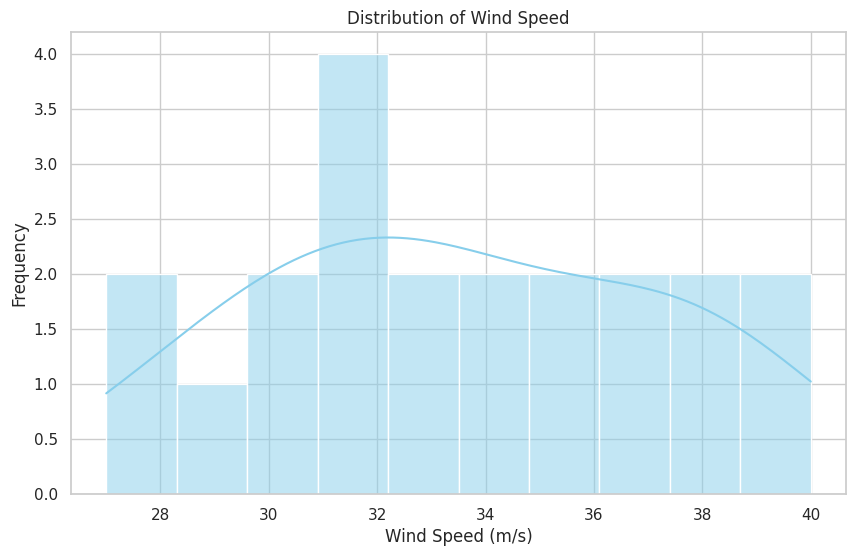

In [9]:
import os, base64

def save_data_url(data_url: str, out_path: str) -> str:
    """
    Saves a URL data (ex. 'data:image/png;base64,...') into a file.
    Returns its path.
    """
    if not data_url.startswith("data:"):
        raise ValueError("The URL is not valid.")
    header, b64 = data_url.split(",", 1)
    with open(out_path, "wb") as f:
        f.write(base64.b64decode(b64))
    return out_path

images_saved = []
files_saved = []

# Scorri l'output del Code Interpreter
for item in getattr(resp_ci, "output", []) or []:
    if getattr(item, "type", None) == "code_interpreter_call":
        for out in getattr(item, "outputs", []) or []:
            otype = getattr(out, "type", None)

            # Case A: inline image as URL data
            if otype == "image" and getattr(out, "url", "").startswith("data:image/"):
                idx = len(images_saved) + 1
                out_path = f"code_interpreter_image_{idx}.png"
                save_data_url(out.url, out_path)
                images_saved.append(out_path)

            # Case B: "real" file with global file_id (less frequent)
            elif otype == "file" and getattr(out, "file_id", None):
                fid = out.file_id
                content = client.files.content(fid).read()   # scarica i bytes
                # Tries to use the filename if provided, otherwise it uses another name
                fname = getattr(out, "filename", None) or f"code_interpreter_file_{len(files_saved)+1}.bin"
                with open(fname, "wb") as f:
                    f.write(content)
                files_saved.append(fname)

print("Saved images:", images_saved)
print("Saved files:", files_saved if files_saved else "No global file was returned.")
display(Image(filename="code_interpreter_image_1.png"))